In [4]:
using ITensors, ITensorMPS
using ITransverse
using Plots
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

false

In [5]:
# System Parameters

# Alcaraz's NNN Self Dual Critical model
N = 50        
lambda = 1.0    # exact critical point (self dual)
p = 0.5         # NNN term (p>0 breakes system's integrability)
dt = 0.1       
T_max = 3     
cutoff = 1e-12
maxdim = 200

# Physical indices
sites = siteinds("S=1/2", N)

50-element Vector{Index{Int64}}:
 (dim=2|id=902|"S=1/2,Site,n=1")
 (dim=2|id=8|"S=1/2,Site,n=2")
 (dim=2|id=20|"S=1/2,Site,n=3")
 (dim=2|id=478|"S=1/2,Site,n=4")
 (dim=2|id=617|"S=1/2,Site,n=5")
 (dim=2|id=715|"S=1/2,Site,n=6")
 (dim=2|id=276|"S=1/2,Site,n=7")
 (dim=2|id=933|"S=1/2,Site,n=8")
 (dim=2|id=876|"S=1/2,Site,n=9")
 (dim=2|id=409|"S=1/2,Site,n=10")
 (dim=2|id=803|"S=1/2,Site,n=11")
 (dim=2|id=615|"S=1/2,Site,n=12")
 (dim=2|id=506|"S=1/2,Site,n=13")
 ⋮
 (dim=2|id=232|"S=1/2,Site,n=39")
 (dim=2|id=990|"S=1/2,Site,n=40")
 (dim=2|id=23|"S=1/2,Site,n=41")
 (dim=2|id=810|"S=1/2,Site,n=42")
 (dim=2|id=240|"S=1/2,Site,n=43")
 (dim=2|id=228|"S=1/2,Site,n=44")
 (dim=2|id=2|"S=1/2,Site,n=45")
 (dim=2|id=318|"S=1/2,Site,n=46")
 (dim=2|id=109|"S=1/2,Site,n=47")
 (dim=2|id=771|"S=1/2,Site,n=48")
 (dim=2|id=376|"S=1/2,Site,n=49")
 (dim=2|id=757|"S=1/2,Site,n=50")

Hamiltonian given by:
$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p \sigma_i^z \sigma_{i+2}^z + p \lambda \sigma_i^x \sigma_{i+1}^x \right)$$

In [6]:
# Hamiltonian

os = OpSum()

# Transverse magnetic field (X)
for j=1:N
    os += -lambda, "X", j
end

# Nearest-neighbour interactions (ZZ y XX)
for j=1:N-1
    os += -1.0, "Z", j, "Z", j+1
    os += -p*lambda, "X", j, "X", j+1
end

# Next-Nearest Neighbour interactions (ZZ)
for j=1:N-2
    os += -p, "Z", j, "Z", j+2
end

H = MPO(os, sites)
println("Max bond dim of Hamiltonian: ", maxlinkdim(H))

Max bond dim of Hamiltonian: 5


Progress: 100%|█████████████████████████████████████████| Time: 1:39:02


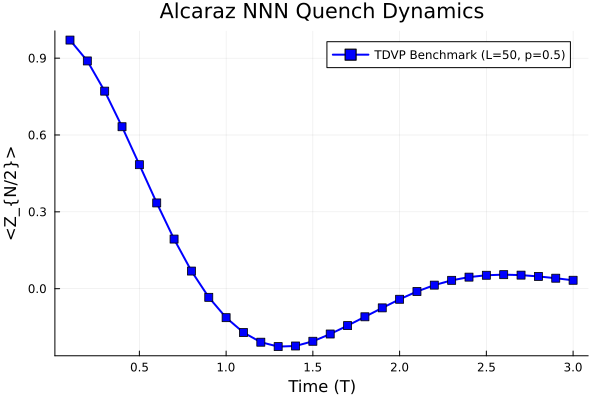

In [10]:
# Initial state: Up state
psi0 = MPS(sites, "Up")
psi_t = copy(psi0)

# We want to measure the observable Z in the middle of the chain
center_site = div(N, 2)
z_vals_tdvp = Float64[]
times = dt:dt:T_max

@showprogress for t in times
    global psi_t = tdvp(H, -im*dt, psi_t; cutoff=cutoff, maxdim=maxdim, nsweeps=2)
    
    val = expect(psi_t, "Z")[center_site]
    push!(z_vals_tdvp, real(val))
end

plot(times, z_vals_tdvp, 
     label="TDVP Benchmark (L=$N, p=$p)", 
     xlabel="Time (T)", 
     ylabel="<Z_{N/2}>",
     lw=2, color=:blue, marker=:square,
     title="Alcaraz NNN Quench Dynamics")

In [11]:
using JLD2

output_file = "tvdp_run.jld2"

jldsave(output_file; 
    times_tdvp = times, 
    z_tdvp = z_vals_tdvp, 
    p_value = p,
    lambda_value = lambda
)

In [4]:
using JLD2

@load "tvdp_run.jld2" times_tdvp z_tdvp

2-element Vector{Symbol}:
 :times_tdvp
 :z_tdvp

-------------------------------------------------------------------------------------------------------------
### TEBD & TROTTERIZATION METHOD

To build $U(\delta t) \approx e^{-i H \delta t}$ for the Alcaraz model, we will use a classic tensor network technique:

1. We first calculate the exact matrix exponential $e^{-i \delta t \cdot h}$ for every single term in the Hamiltonian independently.
2. For the NNN term ($Z_i Z_{i+2}$), the interaction "jumps over", so we mathematically sandwich an Identity matrix in the middle: $Z_i \otimes \mathbb{I}_{i+1} \otimes Z_{i+2}$.
3. We use 2nd-order Trotter expansion to reduce Trotter error.
4. At the end, we create an MPO representing a pure Identity matrix and we "apply" our array of gates to it (so that ITensors sweeps across the chain, absorbs the gates, and compresses the result into our final $U(\delta t)$ MPO).

In [4]:
function build_alcaraz_gates(sites, lambda::Float64, p::Float64, dt::Float64)
    N = length(sites)
    dt_half = dt / 2.0
    gates = ITensor[]
    
    # Half-step NNN
    for j=1:N-2
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    # Half-step NN
    for j=1:N-1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Full-step Transverse Field
    for j=1:N
        h_X = -lambda * op("X", sites[j])
        push!(gates, exp(-im * dt * h_X))
    end
    
    # Half-step NN
    for j=N-1:-1:1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Half-step NNN
    for j=N-2:-1:1
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    return gates
end

build_alcaraz_gates (generic function with 1 method)

In [5]:
# System Parameters
N = 50        
lambda = 1.0    
p = 0.5         
dt = 0.1       
T_max = 3     
cutoff = 1e-12
maxdim = 200

sites = siteinds("S=1/2", N)
center_site = div(N, 2)
times = dt:dt:T_max

# Generate Trotter gates
gates = build_alcaraz_gates(sites, lambda, p, dt)

# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

In [8]:
# STEP 0: Time evolution via direct gate application (TEBD style)
psi_step0 = MPS(sites, "Up")
z_vals_step0 = Float64[]

@showprogress "Step 0 Evolution: " for t in times
    global psi_step0 = apply(gates, psi_step0; cutoff=cutoff, maxdim=maxdim)
    
    normalize!(psi_step0) 
    
    val = expect(psi_step0, "Z")[center_site]
    push!(z_vals_step0, real(val))
end

Step 0 Evolution: 100%|█████████████████████████████████| Time: 0:04:12


In [23]:
# STEP 1: Time evolution via MPO application (IGNORE THIS, IT IS HIGHLY INEFFICIENT, JUST FOR TESTING)
psi_step1 = MPS(sites, "Up")
z_vals_step1 = Float64[]


U_dt = MPO(sites, "Id")
U_dt = apply(gates, U_dt; cutoff=1e-13, maxdim=maxdim)

@showprogress "Step 1 Evolution: " for t in times
    global psi_step1 = apply(U_dt, psi_step1; cutoff=cutoff, maxdim=maxdim)
    
    normalize!(psi_step1) 
    
    val = expect(psi_step1, "Z")[center_site]
    push!(z_vals_step1, real(val))
end

Step 1 Evolution: 100%|█████████████████████████████████| Time: 0:13:46


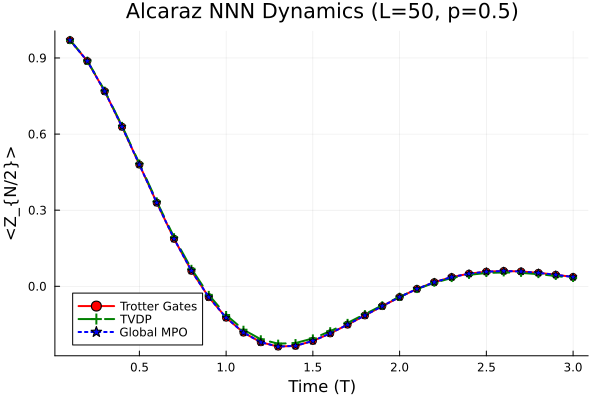

In [24]:
# Plotting
p_plot = plot(times, z_vals_step0, 
    label="Trotter Gates", 
    lw=2, color=:red, marker=:circle)

plot!(p_plot, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:green, marker=:cross, ls=:dash)

plot!(p_plot, times, z_vals_step1, 
    label="Global MPO", 
    lw=2, color=:blue, marker=:star, ls=:dot)

plot!(p_plot, 
    xlabel="Time (T)", 
    ylabel="<Z_{N/2}>",
    title="Alcaraz NNN Dynamics (L=$N, p=$p)",
    legend=:bottomleft)

display(p_plot)

We have a problem though: for the global MPO layer we just constructed, we used "apply()" which applies a global SVD and shifts the gauge, so the MPO is no longer translationally invariant anymore, which ITransverse requires for light cone time evolution.

In [6]:
struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end
ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz_MPO(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    dt_half = dt / 2.0
    gates = ITensor[]
    
    # Half-step NNN
    for j=1:N-2
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    # Half-step NN
    for j=1:N-1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Full-step Transverse Field
    for j=1:N
        h_X = -lambda * op("X", sites[j])
        push!(gates, exp(-im * dt * h_X))
    end
    
    # Half-step NN
    for j=N-1:-1:1
        h_ZZ = -1.0 * op("Z", sites[j]) * op("Z", sites[j+1])
        h_XX = -p * lambda * op("X", sites[j]) * op("X", sites[j+1])
        push!(gates, exp(-im * dt_half * (h_ZZ + h_XX)))
    end
    
    # Half-step NNN
    for j=N-2:-1:1
        h_NNN = -p * op("Z", sites[j]) * op("Id", sites[j+1]) * op("Z", sites[j+2])
        push!(gates, exp(-im * dt_half * h_NNN))
    end
    
    U_dt = MPO(sites, "Id")
    U_dt = apply(gates, U_dt; cutoff=0, maxdim=500)
    
    return U_dt
end

expH_alcaraz_MPO (generic function with 1 method)

In [ ]:
function run_lightcone_quench(mpo_generator::Function; T_max::Float64 = 5.0, dt::Float64 = 0.05, lambda::Float64 = 1.0, p::Float64 = 0.5, cutoff::Float64 = 1e-12, maxdim::Int = 256)
    # Setup Physical System
    s = Index(2, "S=1/2")
    bl = ITensor(ComplexF64, s)
    bl[s => 1] = 1.0 + 0.0im  # Initial state: |Up>

    # Package parameters + Folded Blocks
    mp_alcaraz = AlcarazModel(lambda, p, s)
    tp = tMPOParams(dt, mpo_generator, mp_alcaraz, 0, bl)
    
    # FoldtMPOBlocks extracts the translationally invariant tensor
    fb = FoldtMPOBlocks(tp)

    # Light Cone Parameters
    cutoff = cutoff
    maxdim = maxdim
    t_params = TruncParams(cutoff, maxdim, "left")

    cp = ConeParams(
        truncp = t_params,
        opt_method = "RTM_LR",       
        vwidth = 1                   
    )

    # Observables
    chk = DoCheckpoint(
        "cp_alcaraz_dynamics.jld2";
        params=tp,
        save_at=0, 
        observables = (
            temp_entropy = s -> vn_entanglement_entropy(s.R), 
            
            Z_normed = s -> real(
                first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
                first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
            )
        )
    )

    # Run Simulation
    init_mps = init_cone(fb, 1)
    Nt_final = Int(round(T_max / dt))

    L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

    # Extract Data
    svn_vals_raw = checkpt.history[:temp_entropy]
    
    svn_max = [maximum(real(v)) for v in svn_vals_raw]     
    z_vals = checkpt.history[:Z_normed]
    times_plot = [n * dt for n in 1:length(svn_max)]

    # Plotting
    p1 = plot(times_plot, svn_max, 
         label="Max Transverse SvN (p=$p)", 
         xlabel="Time", 
         ylabel="Temporal Entanglement", 
         lw=2, color=:red, marker=:circle,
         title="Simulation Complexity")

    p2 = plot(times_plot, z_vals, 
         label="<Z> (p=$p, λ=$lambda)", 
         xlabel="Time", 
         ylabel="Expectation Value <Z>", 
         lw=2, color=:green, marker=:circle,
         title="Alcaraz Quench Dynamics")

    display(p1)
    display(p2)
    
    return times_plot, z_vals, svn_max
end

run_lightcone_quench (generic function with 1 method)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-12, maxdim=256) 100% Time: 0:00:45 ( 1.16  s/it)
   Info: [40] χ=31, (L|R) = 9.825901237624297e-23 + 1.0373093205418282e-37im 


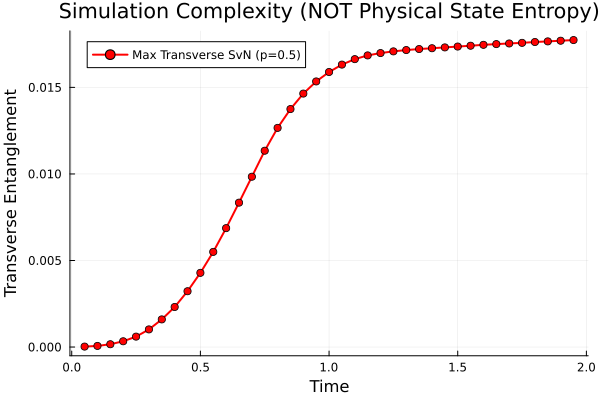

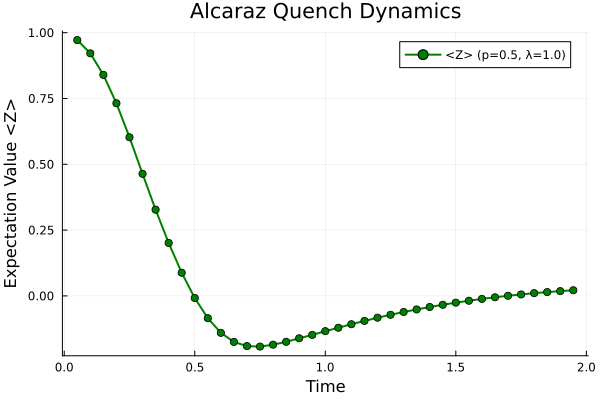

([0.05, 0.1, 0.15000000000000002, 0.2, 0.25, 0.30000000000000004, 0.35000000000000003, 0.4, 0.45, 0.5  …  1.5, 1.55, 1.6, 1.6500000000000001, 1.7000000000000002, 1.75, 1.8, 1.85, 1.9000000000000001, 1.9500000000000002], Any[0.9719710012579502, 0.9215430057311685, 0.8397490083866455, 0.7317427809961546, 0.6026999045574389, 0.4638471242799347, 0.32763744165196457, 0.20116668151808867, 0.08805766652352091, -0.007913319704806899  …  -0.02561260731431175, -0.018384711683449177, -0.011405897655077709, -0.005201184836805246, 0.0005363045319947157, 0.005538969086584826, 0.010474985860167738, 0.014457067902325163, 0.01817127214146304, 0.021483927336584534], [2.56732598068705e-5, 6.505505690394161e-5, 0.00016185441906575214, 0.000333257141289958, 0.000601973691812388, 0.001018546398504417, 0.0015966175463811704, 0.002313688075983633, 0.0032239041728685247, 0.004286199532168368  …  0.017358352987443898, 0.017405980687616656, 0.017458561079659016, 0.01749967916211777, 0.017536790109429108, 0.01757

In [ ]:
t, z, s_trans = run_lightcone_quench(expH_alcaraz_MPO; T_max=3.0, dt=0.05, lambda=1.0, p=0.5, cutoff=1e-12, maxdim=256)

1st approach: let's try to do a "naive" global apply (no truncation), the bond dim will explode exponentially but we can check if the tensors are symmetric for short times and chains

In [ ]:
using LinearAlgebra

function test_strict_mpo_center(N::Int, lambda::Float64, p::Float64, dt::Float64)
    sites = siteinds("S=1/2", N)
    dt_half = dt / 2.0
    gates = ITensor[]

    gates = build_alcaraz_gates(sites, lambda, p, dt)
    U_dt = MPO(sites, "Id")
    
    println("Applying gates with strict SVD truncation...")
    U_dt = apply(gates, U_dt; cutoff=0, maxdim=500)
    
    println("Full MPO Link dimensions: ", linkdims(U_dt))
    
    # Find the center of the chain
    c = div(N, 2)
    W_c = U_dt[c]
    W_c1 = U_dt[c+1]
    
    l_c_minus1 = linkind(U_dt, c-1)
    l_c = linkind(U_dt, c)
    l_c_plus1 = linkind(U_dt, c+1)
    
    dim1 = dim(l_c_minus1)
    dim2 = dim(l_c)
    dim3 = dim(l_c_plus1)
    
    println("--- Bulk Analysis ---")
    println("Center bonds: dim(L_$(c-1)) = $dim1, dim(L_$c) = $dim2, dim(L_$(c+1)) = $dim3")
    
    # Stress-Test the dimensions
    if dim1 != dim2 || dim2 != dim3
        println("FAILURE: The bulk has not converged to a uniform bond dimension.")
        println("The chain is too short (N=$N) or the boundary effects penetrate deeper than expected.")
        return U_dt
    end
    
    # If dimensions match, we map the indices and check the exact numerical symmetry
    W_c1_shifted = replaceinds(W_c1, 
        l_c => l_c_minus1, 
        l_c_plus1 => l_c, 
        sites[c+1] => sites[c], 
        sites[c+1]' => sites[c]'
    )
    
    diff = norm(W_c - W_c1_shifted)
    println("Exact numerical difference between W[$c] and W[$(c+1)]: ", diff)
    
    if diff < 1e-12
        println("SUCCESS: The center bulk is translationally invariant!")
    else
        println("FAILURE: Gauge drift has polluted the bulk symmetry.")
    end
    
    return U_dt
end

test_strict_mpo_center(50, 1.0, 0.5, 0.05)

Applying gates with strict SVD truncation...
Full MPO Link dimensions: [4, 16, 64, 256, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 500, 256, 64, 16, 4]
--- Bulk Analysis ---
Center bonds: dim(L_24) = 500, dim(L_25) = 500, dim(L_26) = 500
Exact numerical difference between W[25] and W[26]: 31.18215951431717
FAILURE: Gauge drift has polluted the bulk symmetry.


50-element MPO:
 ((dim=2|id=882|"S=1/2,Site,n=1")', (dim=2|id=882|"S=1/2,Site,n=1"), (dim=4|id=472|"Link,l=1"))
 ((dim=4|id=472|"Link,l=1"), (dim=2|id=682|"S=1/2,Site,n=2")', (dim=2|id=682|"S=1/2,Site,n=2"), (dim=16|id=237|"Link,l=2"))
 ((dim=16|id=237|"Link,l=2"), (dim=2|id=552|"S=1/2,Site,n=3")', (dim=2|id=552|"S=1/2,Site,n=3"), (dim=64|id=636|"Link,l=3"))
 ((dim=2|id=18|"S=1/2,Site,n=4")', (dim=2|id=18|"S=1/2,Site,n=4"), (dim=256|id=191|"Link,l=4"), (dim=64|id=636|"Link,l=3"))
 ((dim=2|id=118|"S=1/2,Site,n=5")', (dim=2|id=118|"S=1/2,Site,n=5"), (dim=500|id=8|"Link,l=5"), (dim=256|id=191|"Link,l=4"))
 ((dim=2|id=44|"S=1/2,Site,n=6")', (dim=2|id=44|"S=1/2,Site,n=6"), (dim=500|id=116|"Link,l=6"), (dim=500|id=8|"Link,l=5"))
 ((dim=2|id=923|"S=1/2,Site,n=7")', (dim=2|id=923|"S=1/2,Site,n=7"), (dim=500|id=251|"Link,l=7"), (dim=500|id=116|"Link,l=6"))
 ((dim=2|id=582|"S=1/2,Site,n=8")', (dim=2|id=582|"S=1/2,Site,n=8"), (dim=500|id=492|"Link,l=8"), (dim=500|id=251|"Link,l=7"))
 ((dim=2|id=5

--------------------------------------------------------------------------------------------------------

### **Time-Evolution via the Zaletel $W^{II}$ Method**

Standard time-evolution approaches (like Suzuki-Trotter) rely on slicing the chain into separate 2-site gates. However, since the Alcaraz model contains NNN interactions ($Z_i \otimes \mathbb{I}_{i+1} \otimes Z_{i+2}$), which span three sites, trotterizing this geometry destroys translational invariance and introduces severe errors when overlapping spatial terms fail to commute. ITransverse's light cone method does not work well when the MPO does not have translational invariance.

Instead, we use the continuous-time $W^{II}$ method (Zaletel et al., 2015), which maps the exact Hamiltonian MPO directly into a local "scattering matrix", resolving all overlapping quantum operators on a single site to infinite order (machine precision) in $dt$.


#### Step 1: Constructing the Spatial Hamiltonian (Finite State Machine)

We first rewrite the Hamiltonian into a set of "rules" for an assembly line moving from left to right across the chain. Every interaction is broken down into four possible roles (called states):

* $\hat{D}$ **(On-site):** Terms that start and end on the same site ($-\lambda X$).
* $\hat{C}$ **(Initiators):** The *first* operator of a multi-site term ($[Z, \mathbb{O}_2, X]$). 
* $\hat{B}$ **(Terminators):** The *last* operator of a multi-site term ($[-Z, -pZ, -p\lambda X]^T$). 
* $\hat{A}$ **(Propagators):** The "waiting room". If an interaction spans across a site without doing anything, it drops an Identity ($\mathbb{I}$) and moves to the next site. For the NNN term, we need a 1-site gap ($\mathbb{I}$) to bridge the distance. $\hat{A}_{1,2} = \mathbb{I}$, with all other entries zero.

This defines the standard upper-triangular Hamiltonian MPO block ($\chi=N_i + 2 = 5$, with $N_i$ being the number of interaction terms):

$$\hat{W}_H = \begin{pmatrix} \mathbb{I} & \hat{C} & \hat{D} \\ 0 & \hat{A} & \hat{B} \\ 0 & 0 & \mathbb{I} \end{pmatrix}$$


#### Step 2: The $M$ Matrix (Time-Evolution Generator)

To calculate $e^{-i H dt}$ locally on a single site, we define an $8 \times 8$ matrix $M$ (is is a 4x4 matrix whose elements are 2x2 spin matrices). 

$M$ can be seen as a table of transitions. It asks: *"Based on what interactions are arriving from the left ($a$) and leaving to the right ($\bar{a}$), what operator must I apply to this spin?"*

The matrix is divided into four distinct "Channels" (States):
1.  **Row/Col 1 (Vacuum):** No interactions are passing through.
2.  **Row/Col 2 (End):** An interaction arrived from the left to terminate here.
3.  **Row/Col 3 (Start):** A new interaction is starting here and heading right.
4.  **Row/Col 4 (Bridge):** An interaction is passing *through* this site, or multiple interactions are hitting it simultaneously.

For a time step $\tau = -i dt$, the transition matrix is:
$$ M(a, \bar{a}) = \begin{pmatrix} 
\tau \hat{D} & 0 & 0 & 0 \\
\sqrt{\tau} \hat{B}_a & \tau \hat{D} & 0 & 0 \\
\sqrt{\tau} \hat{C}_{\bar{a}} & 0 & \tau \hat{D} & 0 \\
\hat{A}_{a,\bar{a}} & \sqrt{\tau} \hat{C}_{\bar{a}} & \sqrt{\tau} \hat{B}_a & \tau \hat{D}
\end{pmatrix} $$
*(Note: Multi-site terms get $\sqrt{\tau}$ because the total time step $\tau$ is distributed evenly across the sites they span).*


#### Step 3: Overlap Resolution via Matrix Exponentiation

A naive Taylor expansion of the global Hamiltonian fails because operators on the same site might not commute (e.g., an $X$ and a $Z$ hitting the same spin). 

The $W^{II}$ method solves this by calculating the exact Matrix Exponential: 
$$\mathcal{E} = \exp(M) = I + M + \frac{1}{2}M^2 + \dots$$

When the computer calculates $M^2$, it automatically multiplies the block matrices together (e.g., $\tau \hat{C}\hat{B}$). This natively figures out exactly what happens when an Initiator ($\hat{C}$) and a Terminator ($\hat{B}$) crash into the exact same physical site at the exact same time. It evaluates these non-commuting overlaps analytically to infinite order without any SVD truncation.


#### Step 4: Extracting the Time-Evolution MPO

Once the full exponential $\mathcal{E}$ (an $8 \times 8$ matrix) is computed, we extract its four structural corners. These corners represent the core state transitions (Vacuum $\to$ Vacuum, End $\to$ Vacuum, etc.):

$$W^{II}_{1,1} = \mathcal{E}_{1,1}, \quad W^{II}_{1+a,1} = \mathcal{E}_{2,1}, \quad W^{II}_{1,1+\bar{a}} = \mathcal{E}_{3,1}, \quad W^{II}_{1+a,1+\bar{a}} = \mathcal{E}_{4,1}$$

Because the internal state space ($a, \bar{a}$) has dimension 3, this extraction strictly bounds the final time-evolution tensor to a $4 \times 4$ grid of Pauli operators. This yields a highly compressed, perfectly translationally invariant, unitary operator with an $\mathcal{O}(dt^2)$ global error.

In [7]:
# Custom Struct with our model's parameters
import ITransverse: ModelParams, modelparams

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

ITransverse.modelparams(mp::AlcarazModel) = (mp.lambda, mp.p)

function expH_alcaraz_WII(sites::Vector{<:Index}, lambda::Number, p::Number; dt::Number)
    N = length(sites)
    
    I2 = ComplexF64[1 0; 0 1]
    Z  = ComplexF64[1 0; 0 -1]
    X  = ComplexF64[0 1; 1 0]
    O2 = ComplexF64[0 0; 0 0]
    
    # Define Hamiltonian Blocks
    D_op = -lambda .* X
    C_op = [Z, O2, X]
    B_op = [-Z, -p .* Z, -p * lambda .* X]
    
    A_op = fill(O2, 3, 3)
    A_op[1, 2] = I2
    
    tau = -im * dt
    
    W_II = Matrix{Matrix{ComplexF64}}(undef, 4, 4)  # matrix 4x4 of matrices 2x2 (8x8 total)
    
    # we loop over all combinations of a and a_bar (from 1 to 3 possible states) 
    # to construct the 8x8 matrix M that encodes the transition rules of the Zaletel MPO construction
    for a in 1:3
        for a_bar in 1:3
            M = zeros(ComplexF64, 8, 8)
            
            function set_M!(i, j, mat)
                M[2*(i-1)+1 : 2*i, 2*(j-1)+1 : 2*j] .= mat
            end
            
            # Zaletel 8x8 Boson transitions
            set_M!(1, 1, tau .* D_op)
            
            set_M!(2, 1, sqrt(tau) .* B_op[a])
            set_M!(2, 2, tau .* D_op)
            
            set_M!(3, 1, sqrt(tau) .* C_op[a_bar])
            set_M!(3, 3, tau .* D_op)
            
            set_M!(4, 1, A_op[a, a_bar])
            set_M!(4, 2, sqrt(tau) .* C_op[a_bar])
            set_M!(4, 3, sqrt(tau) .* B_op[a])
            set_M!(4, 4, tau .* D_op)
            
    
            E = exp(M)
            
            
            W_II[1, 1] = E[1:2, 1:2]                 
            W_II[1+a, 1] = E[3:4, 1:2]               
            W_II[1, 1+a_bar] = E[5:6, 1:2]           
            W_II[1+a, 1+a_bar] = E[7:8, 1:2]         
        end
    end
    
    links = [Index(4, "Link,l=$i") for i in 1:N-1]
    U_dt = MPO(sites)
    
    for i in 1:N
        s = sites[i]
        
        if i == 1
            W = ITensor(ComplexF64, links[1], s', s)
            for col in 1:4, s1 in 1:2, s2 in 1:2
                W[links[1]=>col, s'=>s1, s=>s2] = W_II[1, col][s1, s2]
            end
            U_dt[i] = W
        elseif i == N
            W = ITensor(ComplexF64, links[i-1], s', s)
            for row in 1:4, s1 in 1:2, s2 in 1:2
                W[links[i-1]=>row, s'=>s1, s=>s2] = W_II[row, 1][s1, s2]
            end
            U_dt[i] = W
        else
            W = ITensor(ComplexF64, links[i-1], links[i], s', s)
            for row in 1:4, col in 1:4, s1 in 1:2, s2 in 1:2
                W[links[i-1]=>row, links[i]=>col, s'=>s1, s=>s2] = W_II[row, col][s1, s2]
            end
            U_dt[i] = W
        end
    end
    
    return U_dt
end

expH_alcaraz_WII (generic function with 1 method)

Progress: 100%|█████████████████████████████████████████| Time: 0:01:54


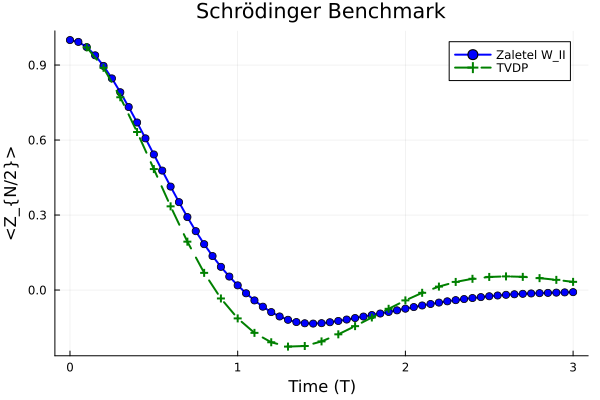

In [13]:
# SCHRÖDINGER TIME EVOLUTION
N = 50
lambda = 1.0
p = 0.5
dt = 0.05
T_max = 3.0
    
sites = siteinds("S=1/2", N)
psi = MPS(sites, "Up")
center_site = div(N, 2)
   
times = 0.0:dt:T_max
z_vals = Float64[]
push!(z_vals, real(expect(psi, "Z")[center_site]))
    
U_dt = expH_alcaraz_WII(sites, lambda, p, dt=dt)
    
@showprogress for t in times[2:end]
    psi = apply(U_dt, psi; cutoff=1e-12, maxdim=400)
    normalize!(psi)
        
    val = real(expect(psi, "Z")[center_site])
    push!(z_vals, val)
end
    
p_plot = plot(times, z_vals, 
    label="Zaletel W_II", 
    xlabel="Time (T)", ylabel="<Z_{N/2}>",
    lw=2, marker=:circle, color=:blue,
    title="Schrödinger Benchmark")

plot!(p_plot, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:green, marker=:cross, ls=:dash)

display(p_plot)

Progress: 100%|█████████████████████████████████████████| Time: 0:04:27


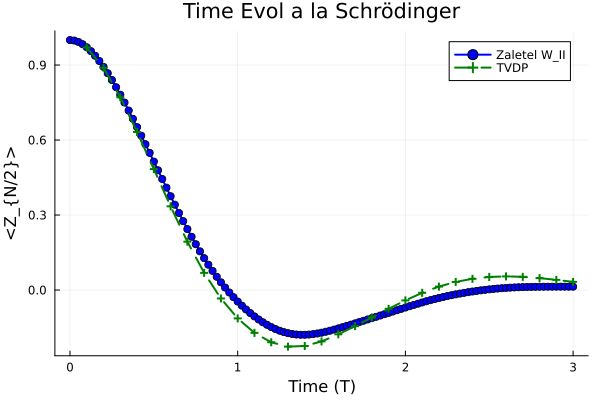

In [10]:
# SCHRÖDINGER TIME EVOLUTION
N = 50
lambda = 1.0
p = 0.5
dt = 0.025
T_max = 3.0
    
sites = siteinds("S=1/2", N)
psi = MPS(sites, "Up")
center_site = div(N, 2)
   
times = 0.0:dt:T_max
z_vals = Float64[]
push!(z_vals, real(expect(psi, "Z")[center_site]))
    
U_dt = expH_alcaraz_WII(sites, lambda, p, dt=dt)
    
@showprogress for t in times[2:end]
    psi = apply(U_dt, psi; cutoff=1e-12, maxdim=400)
    normalize!(psi)
        
    val = real(expect(psi, "Z")[center_site])
    push!(z_vals, val)
end
    
p_plot = plot(times, z_vals, 
    label="Zaletel W_II", 
    xlabel="Time (T)", ylabel="<Z_{N/2}>",
    lw=2, marker=:circle, color=:blue,
    title="Time Evol a la Schrödinger")

plot!(p_plot, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:green, marker=:cross, ls=:dash)

display(p_plot)

Progress: 100%|█████████████████████████████████████████| Time: 0:07:36


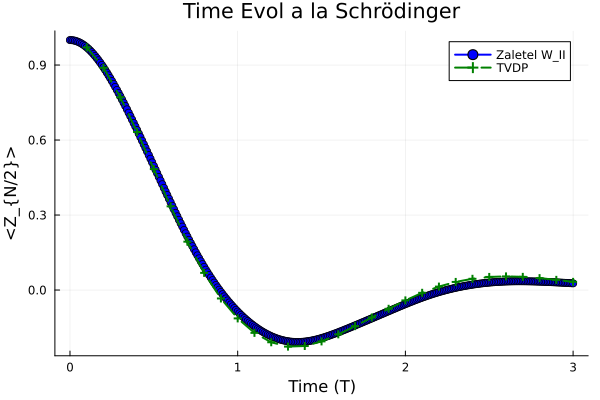

In [12]:
# SCHRÖDINGER TIME EVOLUTION
N = 50
lambda = 1.0
p = 0.5
dt = 0.01
T_max = 3.0
    
sites = siteinds("S=1/2", N)
psi = MPS(sites, "Up")
center_site = div(N, 2)
   
times = 0.0:dt:T_max
z_vals = Float64[]
push!(z_vals, real(expect(psi, "Z")[center_site]))
    
U_dt = expH_alcaraz_WII(sites, lambda, p, dt=dt)
    
@showprogress for t in times[2:end]
    psi = apply(U_dt, psi; cutoff=1e-12, maxdim=400)
    normalize!(psi)
        
    val = real(expect(psi, "Z")[center_site])
    push!(z_vals, val)
end
    
p_plot = plot(times, z_vals, 
    label="Zaletel W_II", 
    xlabel="Time (T)", ylabel="<Z_{N/2}>",
    lw=2, marker=:circle, color=:blue,
    title="Time Evol a la Schrödinger")

plot!(p_plot, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:green, marker=:cross, ls=:dash)

display(p_plot)

## Light Cone Evolution & Entropy

In [16]:
mpo_generator = expH_alcaraz_WII
T_max = 3.0
dt = 0.01
lambda = 1.0
p = 0.5


# Setup Physical System
s = Index(2, "S=1/2")
bl = ITensor(ComplexF64, s)
bl[s => 1] = 1.0 + 0.0im  # Initial state: |Up>

# Package parameters + Folded Blocks
mp_alcaraz = AlcarazModel(lambda, p, s)
tp = tMPOParams(dt, mpo_generator, mp_alcaraz, 0, bl)

# FoldtMPOBlocks extracts the translationally invariant tensor
fb = FoldtMPOBlocks(tp)

inds(init_state) = ((dim=2|id=917|"Site"),)


[ Info: Building WW tensors using expH_alcaraz_WII, parameters AlcarazModel(1.0, 0.5, (dim=2|id=917|"S=1/2"))
[ Info: MPO tensor symmetric in physical(space)  [=bond(time)] indices
┌ Warning: MPO tensor *not* symmetric in bond(space) [=phys(time)] indices
└ @ ITransverse ~/.julia/packages/ITransverse/UeXy0/src/tmpo/fold_tmpo_blocks.jl:56
[ Info: Building WW tensors using expH_alcaraz_WII, parameters AlcarazModel(1.0, 0.5, (dim=2|id=917|"S=1/2"))


[[*Folded*]] tMPO Blocks, type Vector{ComplexF64}
tMPOParams:   dt: 0.01 | nbeta : 0
exp(H) func:  expH_alcaraz_WII  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=917|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]



In [ ]:
# Light Cone Parameters
cutoff = 1e-10
maxdim = 250
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    vwidth = 1                   
)

# Observables
chk = DoCheckpoint(
    "cp_alcaraz_dynamics.jld2";
    params=tp,
    save_at=0, 
    observables = (
        temp_entropy = s -> vn_entanglement_entropy(s.R), 
        
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Run Simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

# Light Cone Parameters
cutoff = 1e-10
maxdim = 250
t_params = TruncParams(cutoff, maxdim, "left")

cp = ConeParams(
    truncp = t_params,
    opt_method = "RTM_LR",       
    vwidth = 1                   
)

# Observables
chk = DoCheckpoint(
    "cp_alcaraz_dynamics.jld2";
    params=tp,
    save_at=0, 
    observables = (
        temp_entropy = s -> vn_entanglement_entropy(s.R), 
        
        Z_normed = s -> real(
            first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
            first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
        )
    )
)

# Run Simulation
init_mps = init_cone(fb, 1)
Nt_final = Int(round(T_max / dt))

L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-10, maxdim=250) 100% Time: 0:46:01 ( 9.23  s/it)
   Info: [300] χ=39, (L|R) = 1.1867519388133714 + 1.313075853288601e-15im 


(MPS(300), MPS(300), DoCheckpoint{tMPOParams{Float64, AlcarazModel, typeof(expH_alcaraz_WII)}, @NamedTuple{temp_entropy::var"#35#36", Z_normed::var"#37#38"}, @NamedTuple{}}("cp_alcaraz_dynamics.jld2", Int64[], tMPOParams:   dt: 0.01 | nbeta : 0
exp(H) func:  expH_alcaraz_WII  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=337|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]
, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10  …  290, 291, 292, 293, 294, 295, 296, 297, 298, 299], (temp_entropy = var"#35#36"(), Z_normed = var"#37#38"()), Dict{Symbol, Vector}(:temp_entropy => Any[[0.0002850018518082487], [0.0005229829866999671, 0.0005429851901493681], [0.0007382833276280466, 0.0009934977102880468, 0.0008002761315765871], [0.000980200278218776, 0.001482505519485919, 0.0015447513232980231, 0.0011173406784793988], [0.0011897732106484998, 0.001902664917403154, 0.0022014688086043994, 0.0020634680187684965, 0.0014111516606240262], [0.0013915197717944184, 0.002303166366982899, 0.002819713205234679, 

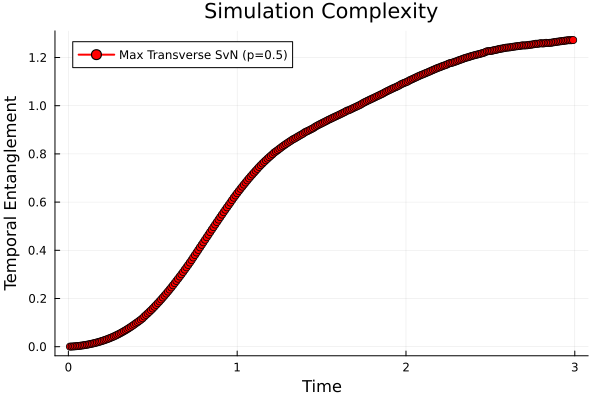

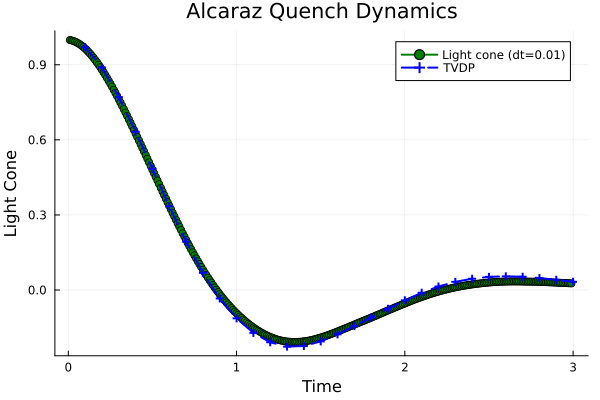

In [15]:
# Extract Data
svn_vals_raw = checkpt.history[:temp_entropy]

svn_max = [maximum(real(v)) for v in svn_vals_raw]     
z_vals = checkpt.history[:Z_normed]
times_plot = [n * dt for n in 1:length(svn_max)]

# Plotting
p1 = plot(times_plot, svn_max, 
        label="Max Transverse SvN (p=$p)", 
        xlabel="Time", 
        ylabel="Temporal Entanglement", 
        lw=2, color=:red, marker=:circle,
        title="Simulation Complexity")

p2 = plot(times_plot, z_vals, 
        label="Light cone (dt=$dt)", 
        xlabel="Time", 
        ylabel="Light Cone", 
        lw=2, color=:green, marker=:circle,
        title="Alcaraz Quench Dynamics")

plot!(p2, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:blue, marker=:cross, ls=:dash)

display(p1)
display(p2)

---

### Comparing Integragle vs Chaotic systems

In [17]:
function compute_lightcone_data(mpo_generator::Function; T_max::Float64 = 3.0, dt::Float64 = 0.05, lambda::Float64 = 1.0, p::Float64 = 0.5, cutoff::Float64 = 1e-12, maxdim::Int = 256)
    s = Index(2, "S=1/2")
    bl = ITensor(ComplexF64, s)
    bl[s => 1] = 1.0 + 0.0im  # |Up>

    mp_alcaraz = AlcarazModel(lambda, p, s)
    tp = tMPOParams(dt, mpo_generator, mp_alcaraz, 0, bl)
    fb = FoldtMPOBlocks(tp)

    cp = ConeParams(
        truncp = TruncParams(cutoff, maxdim, "left"),
        opt_method = "RTM_LR",       
        vwidth = 1                   
    )

    chk = DoCheckpoint(
        "cp_alcaraz_p$(p).jld2"; # Save different files for different p
        params=tp,
        save_at=0, 
        observables = (
            Z_normed = s_env -> real(
                first(compute_expvals(s_env.L, s_env.R, ["Z"], s_env.b)["Z"]) / 
                first(compute_expvals(s_env.L, s_env.R, ["Id"], s_env.b)["Id"])
            ),
        )
    )

    init_mps = init_cone(fb, 1)
    Nt_final = Int(round(T_max / dt))

    _, _, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)

    z_vals = checkpt.history[:Z_normed]
    times_plot = [n * dt for n in 1:length(z_vals)]
    
    return times_plot, z_vals
end

compute_lightcone_data (generic function with 1 method)

In [19]:
# System Parameters
lambda = 1.0
dt = 0.01
T_max = 2.0
cutoff = 1e-10
maxdim = 250

# Trackers
p_values = [0.0, 0.1, 0.5]
labels = ["Ising Exact (p=0.0)", "Weak NNN (p=0.1)", "Strong NNN (p=0.5)"]
colors = [:blue, :orange, :red]
markers = [:circle, :square, :cross]

results_Z = Dict{Float64, Vector{Float64}}()
global_times = Float64[]

@showprogress for p in p_values    
    t_plot, z_data = compute_lightcone_data(expH_alcaraz_WII; T_max=T_max, dt=dt, lambda=lambda, p=p, cutoff=cutoff, maxdim=maxdim)
    
    results_Z[p] = z_data
    global global_times = t_plot
end

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607
[cone(v=1)|RTM_LR] [psi0 >> Op] cutoff=1.0e-10, maxdim=250) 100% Time: 0:10:24 ( 3.14  s/it)
   Info: [200] χ=23, (L|R) = 1.1209815953169415 - 2.4859694958163426e-15im 
Progress: 100%|█████████████████████████████████████████| Time: 0:14:26


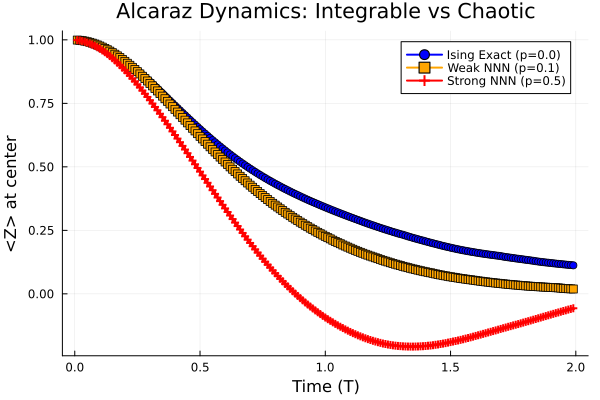

In [20]:
# Plotting

p_plot = plot(
    title="Alcaraz Dynamics: Integrable vs Chaotic",
    xlabel="Time (T)", 
    ylabel="<Z> at center",
    legend=:topright,
    grid=true
)

for (idx, p) in enumerate(p_values)
    plot!(p_plot, global_times, results_Z[p], 
        label=labels[idx], 
        lw=2, 
        color=colors[idx], 
        markershape=markers[idx], 
        markerindices=1:10:length(global_times) 
    )
end

display(p_plot)

---

## Temporal entropies via Transverse Power Method

In [ ]:
function compute_alcaraz_entropies(
    mpo_generator::Function, p::Float64; Tmin::Int, Tmax::Int, dt::Float64=0.05, lambda::Float64=1.0, cutoff::Float64=1e-12, maxdim::Int=256, 
    alg="RTM", Tstep::Int=1, eps_converged::Float64=1e-8
    )
    s = Index(2, "S=1/2")
    bl = ITensor(ComplexF64, s)
    bl[s => 1] = 1.0 + 0.0im    # Initial state: |UP>
    
    mp_alcaraz = AlcarazModel(lambda, p, s)
    tp = tMPOParams(dt, 0.0im, mpo_generator, mp_alcaraz, 0, bl)    
    b = FwtMPOBlocks(tp)
    
    # Power Method Params
    pm_params = PMParams(;
        truncp = (; cutoff=cutoff, maxdim=maxdim, alg=alg), 
        opt_method = :RDM_LR,   # before it was RTM
        cutoffs = [cutoff], 
        maxdims = 2:2:maxdim, 
        itermax = 5000, 
        eps_converged = eps_converged, 
        normalization = "overlap",
        stuck_after = 200,
        compute_fidelity = true
    )

    times = Float64[]
    vn_R = Float64[]
    vn_L = Float64[]
    pseudo_vn = ComplexF64[]
    pseudo_r2 = ComplexF64[]


    for Nsteps in Tmin:Tstep:Tmax
        time_sites = addtags(siteinds(4, Nsteps), "time")
        
        # Transfer Matrix MPO 
        mpo = fw_tMPO(b, time_sites; tr=tp.bl)
        
        # Initial boundary MPS (guess) to start the power method
        start_mps = fw_tMPS(b, time_sites; tr=tp.bl, LR=:right)
        
        # Compute the left and right dominant eigenvectors of the transfer matrix MPO using the power method
        psi_L, psi_R, _ = ITransverse.powermethod_lr(start_mps, mpo, mpo, pm_params)
        
        # Standard VN entropy at the center cut of the time string
        center_bond = div(Nsteps, 2)
        push!(vn_R, real(vn_entanglement_entropy(psi_R)[center_bond]))
        push!(vn_L, real(vn_entanglement_entropy(psi_L)[center_bond]))

        # Generalized VN and Renyi-2 pseudo-entropies
        p_vn = ITransverse.generalized_svd_vn_entropy(psi_L, psi_R)
        p_r2 = ITransverse.gen_renyi2(psi_L, psi_R)
        
        push!(pseudo_vn, p_vn[center_bond])
        push!(pseudo_r2, p_r2[center_bond])
        
        push!(times, Nsteps * dt)
    end
    
    return times, vn_R, vn_L, pseudo_vn, pseudo_r2
end

compute_alcaraz_entropies (generic function with 1 method)

[PM LR|RTM|LR] L=80, cutoff=1.0e-12, maxdim=256, normalize=overlap)   6%  ETA: 0:06:28 (82.77 ms/it)
   Info: [316]  chi=13 | ds=0.018419788290562567 | <R|Rprev> = -1.6428172301607978e-5┌ Warning: PM Stuck after 201/317 steps | ds=0.027954835200365513 | chi=13)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151


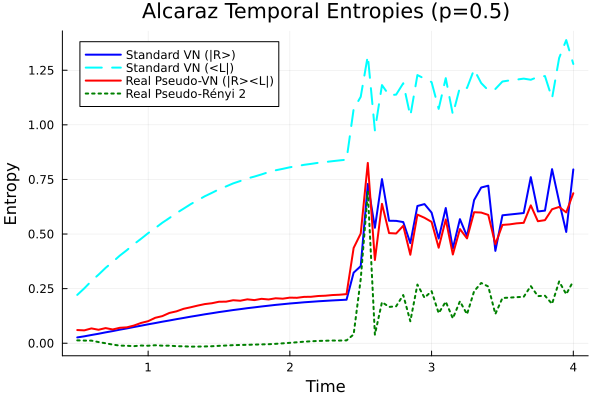

In [ ]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=10, Tmax=80, dt=0.05, cutoff=1e-12, maxdim=256, alg="RTM", Tstep=1, eps_converged=1e-8
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|RTM|RDM_LR] L=300, cutoff=1.0e-12, maxdim=256, normalize=overlap)  14%  ETA: 0:15:19 ( 0.21  s/it)
   Info: [720]  chi=10 | ds=4.41378699817252e-5 | <R|Rprev> = -1.3738222272907664e-7┌ Warning: PM Stuck after 201/721 steps | ds=4.2653182567270465e-5 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151


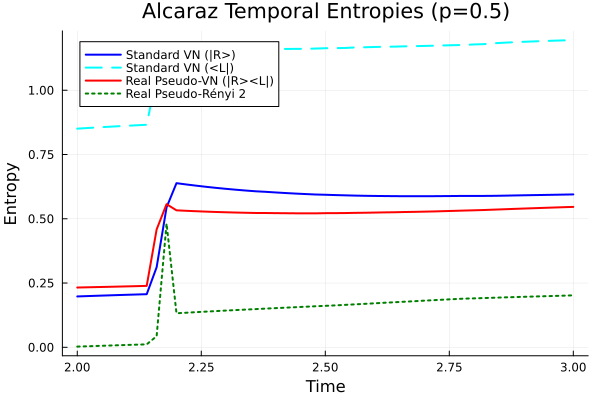

In [11]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=200, Tmax=300, dt=0.01, cutoff=1e-12, maxdim=256, alg="RTM", Tstep=2, eps_converged=1e-6
)
# WE CHANGED OPT METHOD TO RDM_lr


# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|RTM|LR] L=300, cutoff=1.0e-12, maxdim=256, normalize=overlap)  14%  ETA: 0:15:48 ( 0.22  s/it)
   Info: [720]  chi=10 | ds=4.41378699817252e-5 | <R|Rprev> = -1.3738222272907664e-7┌ Warning: PM Stuck after 201/721 steps | ds=4.2653182567270465e-5 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151


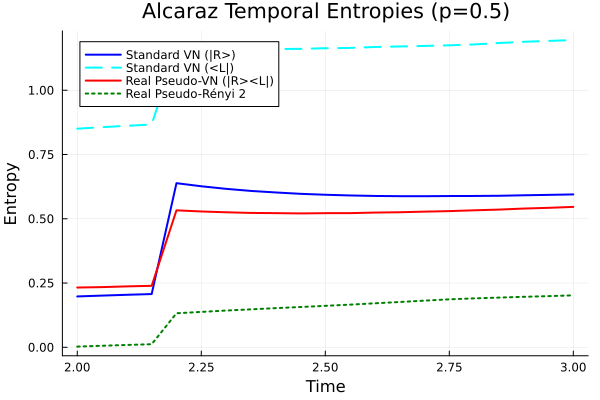

In [ ]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=200, Tmax=300, dt=0.01, cutoff=1e-12, maxdim=256, alg="RTM", Tstep=5, eps_converged=1e-6
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|RTM|LR] L=300, cutoff=1.0e-12, maxdim=256, normalize=overlap)  14%  ETA: 0:16:03 ( 0.23  s/it)
   Info: [720]  chi=10 | ds=4.41378699817252e-5 | <R|Rprev> = -1.3738222272907664e-7┌ Warning: PM Stuck after 201/721 steps | ds=4.2653182567270465e-5 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/yHZ32/src/power_method/pm.jl:151


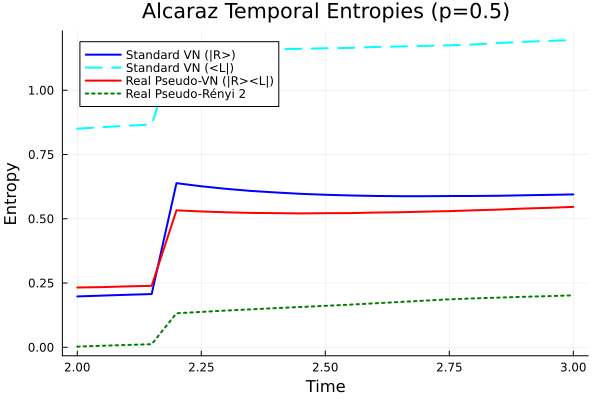

In [38]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=200, Tmax=300, dt=0.01, cutoff=1e-12, maxdim=256, alg="RTM", Tstep=5, eps_converged=1e-8
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

In [12]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=150, Tmax=400, dt=0.01, cutoff=1e-12, maxdim=256, alg="RTM", Tstep=2, eps_converged=1e-6
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=181|"S=1/2,Site") <-> (dim=2|id=181|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=4|id=411|"Link,l=1") <-> (dim=4|id=468|"Link,l=2"), normdiff = 2.0639995962714885
└ @ ITransverse.ITenUtils ~/.julia/packages/ITransverse/yHZ32/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=524|"S=1/2,Site") <-> (dim=2|id=524|"S=1/2,Site")'
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=4|id=836|"Link,l=1") <-> (dim=4|id=354|"Link,l=2"), normdiff = 2.0
└ @ ITransverse.ITenUtils ~/.julia/packages/ITransverse/yHZ32/src/ITenUtils/itensor_utils.jl:93


LoadError: UndefVarError: `powermethod_lr` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

[PM LR|densitymatrix|LR] L=60, cutoff=1.0e-10, maxdim=256, normalize=overlap)  53%  ETA: 0:30:05 ( 0.77  s/it)
   Info: [2659]  chi=48 | ds=1.4354448443776313e-7 | <R|Rprev> = -9.80697005085555e-16[ Info: PM Converged after 2660 steps | ds=7.4135804162267505e-9 | chi=48)


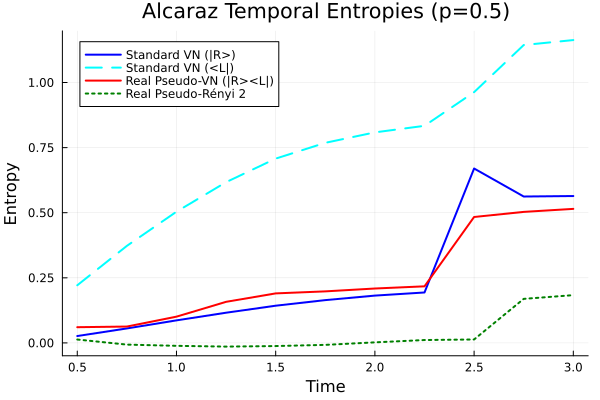

In [35]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=10, Tmax=60, dt=0.05, cutoff=1e-10, maxdim=256, alg="densitymatrix", Tstep=5, eps_converged=1e-6
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

In [ ]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=10, Tmax=300, dt=0.01, cutoff=1e-12, maxdim=512, alg="RDM"
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)

[PM LR|RTM|LR] L=349, cutoff=1.0e-12, maxdim=256, normalize=overlap)   1%  ETA: 0:28:41 ( 0.35  s/it)
   Info: [46]  chi=11 | ds=0.02496688684503856 | <R|Rprev> = -3.3909963478339676e-5

LoadError: InterruptException:

In [ ]:
# Run simulation
t_vals, s_R, s_L, pseudo_s1, pseudo_s2 = compute_alcaraz_entropies(
    expH_alcaraz_WII, 0.5; Tmin=10, Tmax=80, dt=0.05, cutoff=1e-12, maxdim=256, alg="RDM"
)

# Plotting
p_plot = plot(t_vals, s_R, label="Standard VN (|R>)", lw=2, color=:blue, xlabel="Time", ylabel="Entropy", title="Alcaraz Temporal Entropies (p=0.5)")
plot!(p_plot, t_vals, s_L, label="Standard VN (<L|)", lw=2, color=:cyan, ls=:dash)
plot!(p_plot, t_vals, real.(pseudo_s1), label="Real Pseudo-VN (|R><L|)", lw=2, color=:red)
plot!(p_plot, t_vals, real.(pseudo_s2), label="Real Pseudo-Rényi 2", lw=2, color=:green, ls=:dot)

display(p_plot)